In [18]:
!pip install open_clip_torch --break-system-packages

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.optim import lr_scheduler

import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models
import torchvision.transforms.functional as TF
from torchvision.models import ResNet50_Weights

import open_clip
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from sklearn.manifold import TSNE

from tqdm import tqdm
from pathlib import Path
from sklearn.metrics import f1_score

SEED = 6304
import copy
from sklearn.model_selection import StratifiedShuffleSplit
from torch.utils.data import Subset

def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [19]:
!pip install pystiche

In [20]:
!git clone --depth 1 https://github.com/naoto0804/pytorch-AdaIN.git
!mkdir -p pytorch-AdaIN/models
!curl -sL -o pytorch-AdaIN/models/decoder.pth "https://github.com/naoto0804/pytorch-AdaIN/releases/download/v0.0.0/decoder.pth"
!curl -sL -o pytorch-AdaIN/models/vgg_normalised.pth "https://github.com/naoto0804/pytorch-AdaIN/releases/download/v0.0.0/vgg_normalised.pth"

fatal: destination path 'pytorch-AdaIN' already exists and is not an empty directory.


In [21]:
import os
print(os.getcwd())
print(os.listdir())

/kaggle/working
['.virtual_documents', 'data', 'pytorch-AdaIN']


In [22]:
from torchvision.models import ViT_B_16_Weights

resnet_weights = ResNet50_Weights.IMAGENET1K_V2
resnet_model = models.resnet50(weights = resnet_weights)
vit_weights = ViT_B_16_Weights.IMAGENET1K_V1
vit_model = models.vit_b_16(weights=vit_weights)

resnet_transform = resnet_weights.transforms()
vit_transform = vit_weights.transforms()

clip_model_raw, _, clip_preprocess = open_clip.create_model_and_transforms(
    "ViT-B-32", pretrained="openai"
)

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


In [23]:
class CLIPVisualNormalized(nn.Module):
    """Wraps CLIP's visual tower and L2-normalizes the embedding, as required."""
    def __init__(self, visual_model):
        super().__init__()
        self.visual = visual_model

    def forward(self, x):
        feats = self.visual(x)
        feats = feats / feats.norm(dim=-1, keepdim=True)
        return feats

In [24]:
resnet_model.fc = nn.Identity()
resnet_model.eval().to(device)
for params in resnet_model.parameters():
    params.requires_grad = False

vit_model.heads = nn.Identity()
vit_model.eval().to(device)
for p in vit_model.parameters():
    p.requires_grad = False

clip_model_raw = clip_model_raw.to(device)
clip_model_raw.eval()
clip_model = CLIPVisualNormalized(clip_model_raw.visual)
clip_tokenizer = open_clip.get_tokenizer("ViT-B-32")
clip_model.eval().to(device)
for p in clip_model.parameters():
    p.requires_grad = False

backbones = {
    "ResNet-50": (resnet_model, 2048, resnet_transform),
    "ViT-B/16": (vit_model, 768, vit_transform),
    "CLIP ViT-B/32": (clip_model, 512, clip_preprocess),
}

In [25]:
def load_stl10_raw(transform):
    train_full = datasets.STL10(root="./data", split="train", download=True, transform=transform)
    test = datasets.STL10(root="./data", split="test", download=True, transform=transform)
    return train_full, test

def stratified_split_indices(labels, seed=SEED, val_fraction=0.2):
    splitter = StratifiedShuffleSplit(n_splits=1, test_size=val_fraction, random_state=seed)
    train_idx, val_idx = next(splitter.split(np.zeros(len(labels)), labels))
    return train_idx, val_idx

In [26]:
@torch.no_grad()
def extract_features(model, dataloader):
    all_feats = []
    all_labels = []
    for img, labels in tqdm(dataloader):
        img = img.to(device)
        feats = model(img)
        if feats.ndim > 2:
            feats = feats.flatten(1)
        all_feats.append(feats.cpu())
        all_labels.append(labels)
    return torch.cat(all_feats), torch.cat(all_labels)

In [27]:
criterion = nn.CrossEntropyLoss()
def train_probe(feat_dim, train_feats, train_labels, val_feats, val_labels, seed=SEED):
    set_seed(seed)

    train_feats, val_feats = train_feats.to(device), val_feats.to(device)
    train_labels, val_labels = train_labels.to(device), val_labels.to(device)
    classifier = nn.Linear(feat_dim, 10).to(device)
    optimizer = optim.AdamW(classifier.parameters(), lr=1e-3, weight_decay=1e-4)

    best_state = None
    epochs = 50
    not_imp_epoch = 0
    best_val_acc = -1.0
    epochs_without_improvement = 0
    for epoch in tqdm(range(epochs)):
        classifier.train()
        optimizer.zero_grad()
        output = classifier(train_feats)
        loss = criterion(output, train_labels)
        loss.backward()
        optimizer.step()

        classifier.eval()
        with torch.no_grad():
            val_preds = classifier(val_feats).argmax(dim=1)
            val_acc = (val_preds == val_labels).float().mean().item()
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(classifier.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
        
        print(f"  epoch {epoch+1:02d} | train_loss {loss.item():.4f} | val_acc {val_acc:.4f}")

        if epochs_without_improvement >= 5:
            print(f"  Early stopping at epoch {epoch+1} (no improvement for 5 epochs)")
            break

    classifier.load_state_dict(best_state)
    return classifier, best_val_acc
    

In [28]:
@torch.no_grad()
def evaluate_probe(classifier, test_feats, test_labels):
    classifier.eval()
    test_feats, test_labels = test_feats.to(device), test_labels.to(device)
    preds = classifier(test_feats).argmax(dim=1)
    return (preds == test_labels).float().mean().item()

In [29]:
STL10_CLASSES = ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']
@torch.no_grad()
def zeroshot(test_feats, test_labels):
    prompts =[]
    for c in STL10_CLASSES:
        prompts.append(f"a photo of a {c}.")

    tokens = clip_tokenizer(prompts).to(device)
    text_feats = clip_model_raw.encode_text(tokens)
    text_feats = text_feats / text_feats.norm(dim=-1, keepdim=True)
    test_feats = test_feats.to(device)
    test_labels= test_labels.to(device)
    logits = test_feats @ text_feats.T
    preds = logits.argmax(dim=1)
    acc = (preds == test_labels).float().mean().item()
    
    return acc

In [30]:
results = {}
for name, (model, feat_dim, transform) in backbones.items():
    train_set, test_set = load_stl10_raw(transform)
    all_labels = np.array(train_set.labels)
    train_idx, val_idx = stratified_split_indices(all_labels, seed=SEED)
    train_sub = Subset(train_set, train_idx)
    val_sub = Subset(train_set, val_idx)
    train_loader = DataLoader(train_sub,batch_size = 64, shuffle=True)
    val_loader = DataLoader(val_sub, batch_size=64, shuffle=True)
    test_loader = DataLoader(test_set, batch_size=64, shuffle=False, num_workers=2)

    train_feats, train_labels  = extract_features(model, train_loader)
    test_feats, test_labels = extract_features(model, test_loader)
    val_feats, val_labels = extract_features(model, val_loader)
    classifier, best_val_acc = train_probe(feat_dim, train_feats, train_labels, val_feats, val_labels, seed=SEED)
    test_acc = evaluate_probe(classifier, test_feats, test_labels)

    results[name] = {"val_acc": best_val_acc, "test_acc": test_acc, "classifier": classifier}
    print(f"{name}: best val_acc={best_val_acc:.4f}, test_acc={test_acc:.4f}")

    if name == "CLIP ViT-B/32":
        z_acc = zeroshot(test_feats, test_labels)
        results[name]["zero_shot_acc"] = z_acc
        print(f"{name} zero-shot test_acc: {z_acc:.4f}")

 64%|██████▍   | 32/50 [00:00<00:00, 688.24it/s]


  epoch 01 | train_loss 2.3144 | val_acc 0.1920
  epoch 02 | train_loss 2.2254 | val_acc 0.3370
  epoch 03 | train_loss 2.1387 | val_acc 0.5150
  epoch 04 | train_loss 2.0545 | val_acc 0.6450
  epoch 05 | train_loss 1.9727 | val_acc 0.7440
  epoch 06 | train_loss 1.8935 | val_acc 0.7910
  epoch 07 | train_loss 1.8167 | val_acc 0.8300
  epoch 08 | train_loss 1.7424 | val_acc 0.8580
  epoch 09 | train_loss 1.6706 | val_acc 0.8800
  epoch 10 | train_loss 1.6014 | val_acc 0.8890
  epoch 11 | train_loss 1.5347 | val_acc 0.8980
  epoch 12 | train_loss 1.4706 | val_acc 0.9080
  epoch 13 | train_loss 1.4090 | val_acc 0.9150
  epoch 14 | train_loss 1.3498 | val_acc 0.9200
  epoch 15 | train_loss 1.2932 | val_acc 0.9250
  epoch 16 | train_loss 1.2390 | val_acc 0.9290
  epoch 17 | train_loss 1.1872 | val_acc 0.9330
  epoch 18 | train_loss 1.1378 | val_acc 0.9390
  epoch 19 | train_loss 1.0907 | val_acc 0.9430
  epoch 20 | train_loss 1.0457 | val_acc 0.9440
  epoch 21 | train_loss 1.0029 | val_acc

 62%|██████▏   | 31/50 [00:00<00:00, 713.94it/s]


  epoch 01 | train_loss 2.3249 | val_acc 0.2380
  epoch 02 | train_loss 2.1562 | val_acc 0.4360
  epoch 03 | train_loss 1.9929 | val_acc 0.5750
  epoch 04 | train_loss 1.8358 | val_acc 0.6880
  epoch 05 | train_loss 1.6857 | val_acc 0.7590
  epoch 06 | train_loss 1.5434 | val_acc 0.8160
  epoch 07 | train_loss 1.4098 | val_acc 0.8530
  epoch 08 | train_loss 1.2853 | val_acc 0.8840
  epoch 09 | train_loss 1.1705 | val_acc 0.9050
  epoch 10 | train_loss 1.0654 | val_acc 0.9230
  epoch 11 | train_loss 0.9699 | val_acc 0.9360
  epoch 12 | train_loss 0.8837 | val_acc 0.9500
  epoch 13 | train_loss 0.8063 | val_acc 0.9530
  epoch 14 | train_loss 0.7370 | val_acc 0.9540
  epoch 15 | train_loss 0.6753 | val_acc 0.9580
  epoch 16 | train_loss 0.6203 | val_acc 0.9600
  epoch 17 | train_loss 0.5714 | val_acc 0.9610
  epoch 18 | train_loss 0.5278 | val_acc 0.9590
  epoch 19 | train_loss 0.4890 | val_acc 0.9610
  epoch 20 | train_loss 0.4544 | val_acc 0.9620
  epoch 21 | train_loss 0.4234 | val_acc

 88%|████████▊ | 44/50 [00:00<00:00, 705.05it/s]

  epoch 01 | train_loss 2.3005 | val_acc 0.1540
  epoch 02 | train_loss 2.2943 | val_acc 0.2110
  epoch 03 | train_loss 2.2881 | val_acc 0.2720
  epoch 04 | train_loss 2.2819 | val_acc 0.3370
  epoch 05 | train_loss 2.2757 | val_acc 0.3890
  epoch 06 | train_loss 2.2696 | val_acc 0.4500
  epoch 07 | train_loss 2.2634 | val_acc 0.5190
  epoch 08 | train_loss 2.2573 | val_acc 0.6090
  epoch 09 | train_loss 2.2511 | val_acc 0.6840
  epoch 10 | train_loss 2.2450 | val_acc 0.7630
  epoch 11 | train_loss 2.2389 | val_acc 0.8300
  epoch 12 | train_loss 2.2328 | val_acc 0.8700
  epoch 13 | train_loss 2.2267 | val_acc 0.9020
  epoch 14 | train_loss 2.2206 | val_acc 0.9270
  epoch 15 | train_loss 2.2145 | val_acc 0.9400
  epoch 16 | train_loss 2.2084 | val_acc 0.9500
  epoch 17 | train_loss 2.2024 | val_acc 0.9580
  epoch 18 | train_loss 2.1963 | val_acc 0.9610
  epoch 19 | train_loss 2.1903 | val_acc 0.9660
  epoch 20 | train_loss 2.1843 | val_acc 0.9680
  epoch 21 | train_loss 2.1782 | val_acc

In [31]:
import json

def select_balanced_test_subset(test_dataset, total_n=500, seed=6304):
    labels = np.array(test_dataset.labels)
    classes = np.unique(labels)
    target_per_class = total_n // len(classes)
    imbalance_report={}
    rng = np.random.RandomState(seed)
    selected_indices = []
    for c in classes:
        class_indices = np.where(labels == c)[0]
        rng.shuffle(class_indices)
        selected_indices.extend(class_indices[:target_per_class])
        n_take = min(target_per_class, len(class_indices))
        if n_take < target_per_class:                         
            imbalance_report[class_names[c]] = {              
                "requested": target_per_class,
                "available": len(class_indices),
                "used": n_take,
            }
    return sorted(selected_indices), imbalance_report
    
test_full_raw = datasets.STL10(root="./data", split="test", download=True) 
selected_indices, imbalance_report = select_balanced_test_subset(test_full_raw, total_n=500, seed=SEED)

print(f"Selected {len(selected_indices)} images total.")
if imbalance_report:
    for cls, info in imbalance_report.items():
        print(f"  {cls}: requested {info['requested']}, only {info['available']} available, used {info['used']}")
else:
    print("No class imbalance — every class had at least 50 test images available.")

selected_indices = [int(i) for i in selected_indices]
with open("selected_test_indices.json", "w") as f:
    json.dump({
        "seed": SEED,
        "total_requested": 500,
        "target_per_class": 50,
        "selected_indices": selected_indices,
        "imbalance_report": imbalance_report,
    }, f, indent=2)

Selected 500 images total.
No class imbalance — every class had at least 50 test images available.


In [32]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),  
])

test_full= datasets.STL10(root="./data", split="test", download=True, transform=transform)
eval_subset = Subset(test_full, selected_indices)

all_images, all_labels=[],[]
for images, labels in eval_subset:   
    all_images.append(images)
    all_labels.append(labels)
    
clean_images = torch.stack(all_images)
clean_labels = torch.tensor(all_labels)

In [33]:
BACKBONE_STATS = {
    "ResNet-50":     (resnet_transform.mean, resnet_transform.std),
    "ViT-B/16":      (vit_transform.mean, vit_transform.std),
    "CLIP ViT-B/32": ((0.48145466, 0.4578275, 0.40821073), (0.26862954, 0.26130258, 0.27577711)),
}


def normalize_batch(img_batch, mean, std):
    mean_t = torch.tensor(mean, device=img_batch.device).view(1, 3, 1, 1)
    std_t = torch.tensor(std, device=img_batch.device).view(1, 3, 1, 1)
    return (img_batch - mean_t) / std_t

In [34]:
def eval_conf(feats,labels, classifier):
    feats, labels = feats.to(device), labels.to(device)
    output = classifier(feats)
    probs = torch.softmax(output, dim=1)
    pred = output.argmax(1)
    acc = (pred==labels).float().mean().item()
    max_conf = probs.max(dim=1).values
    preds_np, labels_np = pred.cpu().numpy(), labels.cpu().numpy()
    macro_f1 = f1_score(labels_np, preds_np, average="macro")
    mean_max_conf = max_conf.mean().item()
    return {
        "accuracy": acc,
        "macro_f1": macro_f1,
        "mean_max_confidence": mean_max_conf,
        "preds": preds_np,
    }
    

In [35]:
@torch.no_grad()
def zeroshot_conf(test_feats, test_labels):
    prompts =[]
    for c in STL10_CLASSES:
        prompts.append(f"a photo of a {c}.")

    tokens = clip_tokenizer(prompts).to(device)
    text_feats = clip_model_raw.encode_text(tokens)
    text_feats = text_feats / text_feats.norm(dim=-1, keepdim=True)
    test_feats = test_feats.to(device)
    test_labels= test_labels.to(device)
    logit_scale = clip_model_raw.logit_scale.exp()
    logits = logit_scale *(test_feats @ text_feats.T)
    preds = logits.argmax(dim=1)
    acc = (preds == test_labels).float().mean().item()
    probs= torch.softmax(logits, dim=1)
    max_conf = probs.max(dim=1).values
    preds_np, labels_np = preds.cpu().numpy(), test_labels.cpu().numpy()
    macro_f1 = f1_score(labels_np, preds_np, average="macro")
    mean_max_conf = max_conf.mean().item()
    return {
        "accuracy": acc,
        "macro_f1": macro_f1,
        "mean_max_confidence": mean_max_conf,
        "preds": preds_np, 
    }


In [36]:
@torch.no_grad()
def eval_results(image_batch,labels):
    all_results = {}
    feats_store={}
    for name, (model,_,_) in backbones.items():
        mean, std = BACKBONE_STATS[name]
        
        images = normalize_batch(image_batch.to(device), mean, std)
        feats = model(images)
        if feats.ndim > 2:
            feats = feats.flatten(1)
           
        feats_store[name]= feats
        all_results[name]= eval_conf(feats, labels, results[name]["classifier"])
    all_results["CLIP Zero-Shot"] = zeroshot_conf(
        feats_store["CLIP ViT-B/32"], labels
    )
    return all_results
    
all_res = eval_results(clean_images, clean_labels)
for name, res in all_res.items():
    print(f"{name:<18} {res['accuracy']:>10.4f} {res['macro_f1']:>10.4f} {res['mean_max_confidence']:>10.4f}")
        

ResNet-50              0.9400     0.9401     0.4995
ViT-B/16               0.9620     0.9623     0.7799
CLIP ViT-B/32          0.9660     0.9657     0.1276
CLIP Zero-Shot         0.9340     0.9328     0.9264


## Color Bias

In [37]:
gray = TF.rgb_to_grayscale(clean_images,num_output_channels=3)
hue_factor=0.3
hue_images = TF.adjust_hue(clean_images, hue_factor)

gray_res = eval_results(gray, clean_labels)
for name, res in gray_res.items():
    print(f"{name:<18} {res['accuracy']:>10.4f} {res['macro_f1']:>10.4f} {res['mean_max_confidence']:>10.4f}")
    

ResNet-50              0.9180     0.9187     0.5330
ViT-B/16               0.9420     0.9422     0.7846
CLIP ViT-B/32          0.9200     0.9192     0.1249
CLIP Zero-Shot         0.8980     0.8976     0.9139


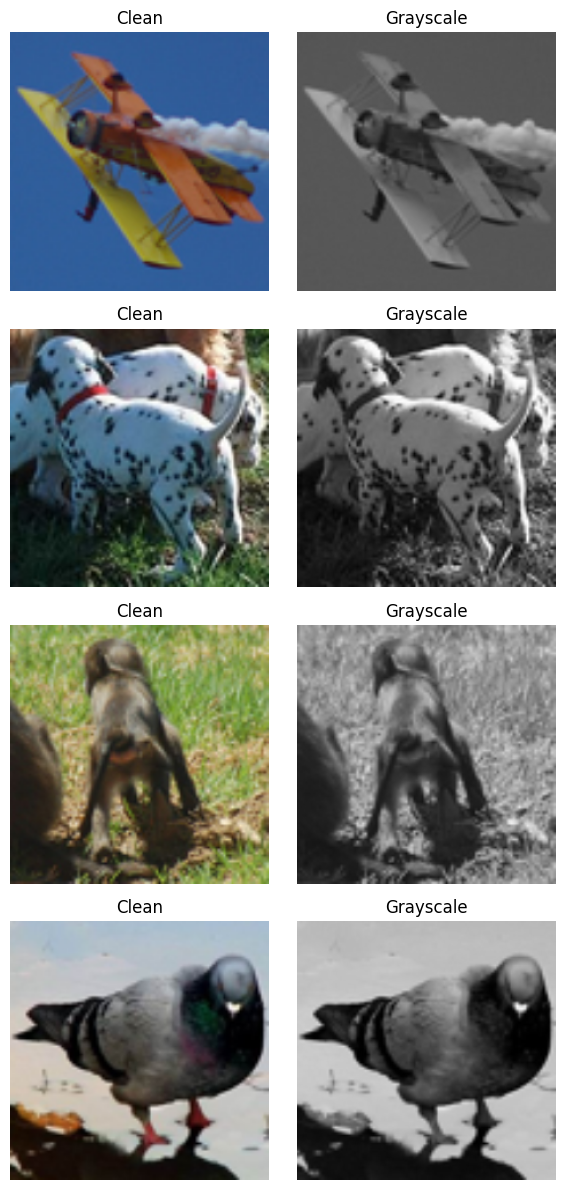

In [38]:
n_show = 4
fig, axes = plt.subplots(n_show, 2, figsize=(6, 3 * n_show))

for i in range(n_show):
    axes[i, 0].imshow(clean_images[i].permute(1, 2, 0)); axes[i, 0].set_title("Clean"); axes[i, 0].axis("off")
    axes[i, 1].imshow(gray[i].permute(1, 2, 0)); axes[i, 1].set_title("Grayscale"); axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

In [39]:
hue_res = eval_results(hue_images, clean_labels)
for name, res in hue_res.items():
    print(f"{name:<18} {res['accuracy']:>10.4f} {res['macro_f1']:>10.4f} {res['mean_max_confidence']:>10.4f}")
        

ResNet-50              0.8980     0.8987     0.5477
ViT-B/16               0.9180     0.9172     0.7573
CLIP ViT-B/32          0.9280     0.9285     0.1232
CLIP Zero-Shot         0.9080     0.9069     0.8989


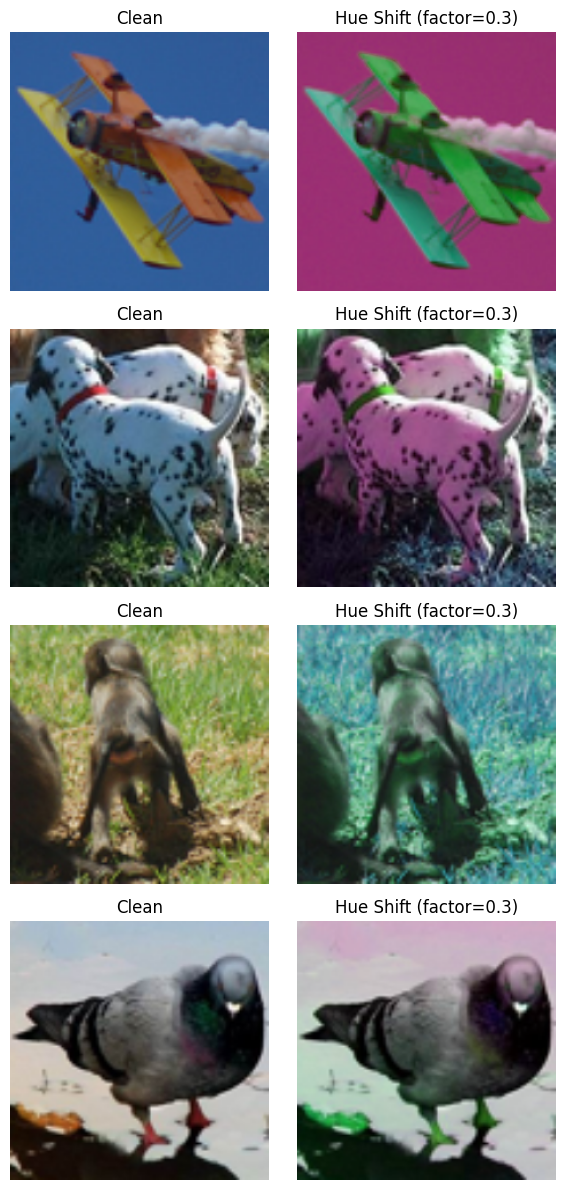

In [40]:
fig, axes = plt.subplots(n_show, 2, figsize=(6, 3 * n_show))

for i in range(n_show):
    axes[i, 0].imshow(clean_images[i].permute(1, 2, 0)); axes[i, 0].set_title("Clean"); axes[i, 0].axis("off")
    axes[i, 1].imshow(hue_images[i].permute(1, 2, 0)); axes[i, 1].set_title(f"Hue Shift (factor={hue_factor})"); axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

## Shape/Texture

In [41]:
CUE_CONFLICT_PAIRS = [
    ("cat", "dog"),
    ("airplane", "ship"),
    ("horse", "deer"),
    ("car", "truck"),
    ("bird", "monkey"),
]
class_to_idx = {}
for i, name in enumerate(STL10_CLASSES):
    class_to_idx[name] = i
DIRECTED_PAIRS = []
for a, b in CUE_CONFLICT_PAIRS:
    DIRECTED_PAIRS.append((a, b))  # content=a, style=b
    DIRECTED_PAIRS.append((b, a))

In [42]:
import sys
sys.path.insert(0, "/kaggle/working/pytorch-AdaIN")
import net
from function import adaptive_instance_normalization as real_adain
adain_vgg = net.vgg
adain_vgg.load_state_dict(torch.load("/kaggle/working/pytorch-AdaIN/models/vgg_normalised.pth", map_location="cpu"))
adain_vgg = nn.Sequential(*list(adain_vgg.children())[:31])  # truncate to relu4_1, matching the paper's design
adain_vgg.eval().to(device)
for p in adain_vgg.parameters():
    p.requires_grad = False

adain_decoder = net.decoder
adain_decoder.load_state_dict(torch.load("/kaggle/working/pytorch-AdaIN/models/decoder.pth", map_location="cpu"))
adain_decoder.eval().to(device)
for p in adain_decoder.parameters():
    p.requires_grad = False

print("Real AdaIN loaded: naoto0804/pytorch-AdaIN (Huang & Belongie, 2017)")

Real AdaIN loaded: naoto0804/pytorch-AdaIN (Huang & Belongie, 2017)


In [43]:
@torch.no_grad()
def style_transfer_fn(content_img, style_img):
    content = content_img.unsqueeze(0).to(device)
    style = style_img.unsqueeze(0).to(device)
    content_f = adain_vgg(content)
    style_f = adain_vgg(style)
    feat = real_adain(content_f, style_f)
    stylized = adain_decoder(feat)
    return stylized.clamp(0, 1).squeeze(0).cpu()
    
def is_valid_stylization(img, min_std=0.03, max_uniform_frac=0.6):
    std = img.std().item()
    frac_clipped = ((img <= 0.01) | (img >= 0.99)).float().mean().item()
    return std >= min_std and frac_clipped <= max_uniform_frac

In [44]:
TARGET_DIRECTION = 20
cue_conflict_images, cue_conflict_meta, cue_source = [], [], []
accepted_count,rejected_count = 0, 0
for content_cls, style_cls in DIRECTED_PAIRS:  
    content_pool = clean_images[clean_labels == class_to_idx[content_cls]]
    style_pool = clean_images[clean_labels == class_to_idx[style_cls]]
    accepted_perdir = 0
    attempt = 0
    while accepted_perdir < TARGET_DIRECTION:
        content_img = content_pool[attempt % len(content_pool)]
        style_img = style_pool[attempt % len(style_pool)]
        hybrid = style_transfer_fn(content_img,style_img)
        if is_valid_stylization(hybrid):
            cue_conflict_images.append(hybrid)
            cue_conflict_meta.append({
                "content": content_cls,
                "style": style_cls
            })
            cue_source.append(content_img)
            accepted_count += 1
            accepted_perdir += 1
        else:
            rejected_count += 1
        attempt += 1
        
cue_conflict_images = torch.stack(cue_conflict_images)
cue_source = torch.stack(cue_source)
print(f"Accepted: {accepted_count}")
print(f"Rejected: {rejected_count}")
print(f"Total attempted: {accepted_count + rejected_count}")

Accepted: 200
Rejected: 0
Total attempted: 200


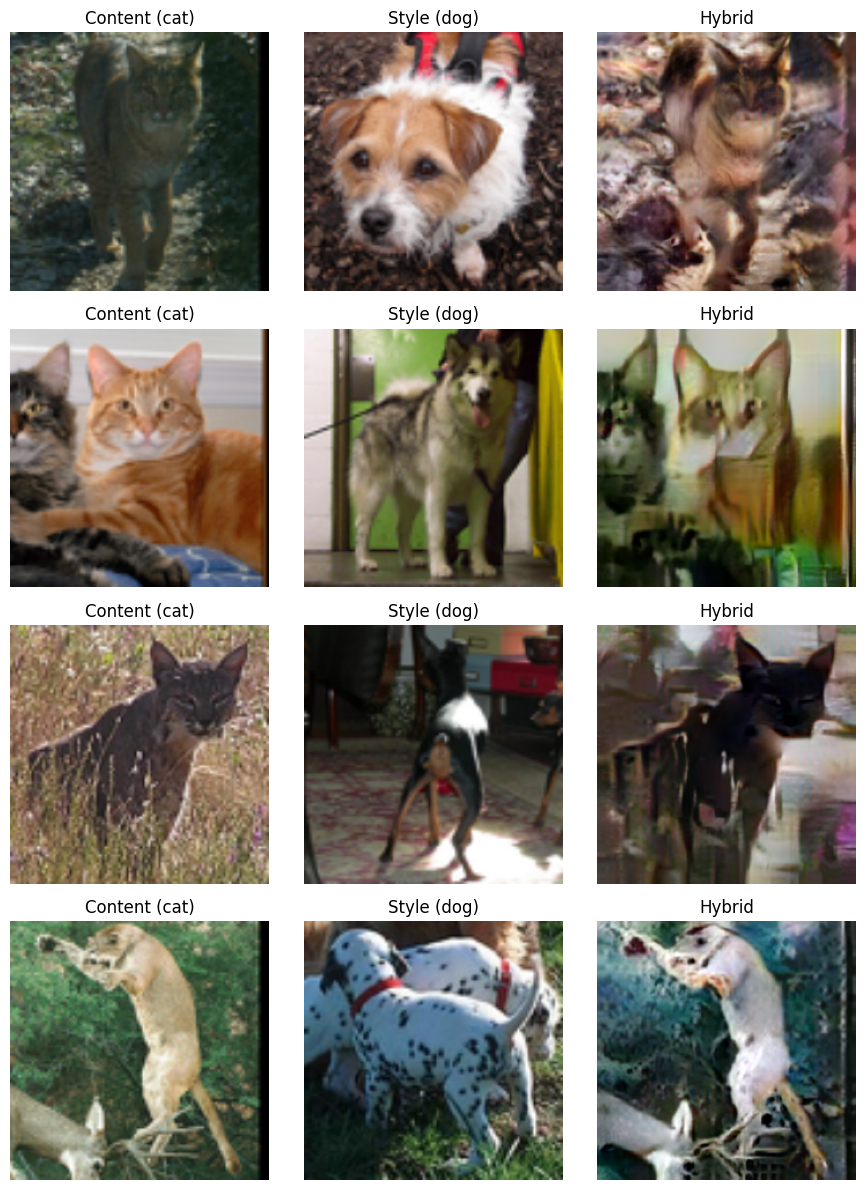

In [45]:
import random
def show_multiple_samples(content_cls, style_cls, n_samples=4, seed=SEED):
    rng = random.Random(seed)
    content_pool = clean_images[clean_labels == class_to_idx[content_cls]]
    style_pool = clean_images[clean_labels == class_to_idx[style_cls]]

    fig, axes = plt.subplots(n_samples, 3, figsize=(9, 3 * n_samples))

    for row in range(n_samples):
        content_img = content_pool[rng.randrange(len(content_pool))]
        style_img = style_pool[rng.randrange(len(style_pool))]
        hybrid = style_transfer_fn(content_img, style_img)

        axes[row, 0].imshow(content_img.permute(1, 2, 0)); axes[row, 0].set_title(f"Content ({content_cls})")
        axes[row, 1].imshow(style_img.permute(1, 2, 0)); axes[row, 1].set_title(f"Style ({style_cls})")
        axes[row, 2].imshow(hybrid.permute(1, 2, 0)); axes[row, 2].set_title("Hybrid")
        for ax in axes[row]:
            ax.axis("off")

    plt.tight_layout()
    plt.show()

show_multiple_samples("cat", "dog", n_samples=4)

In [46]:
content_labels_idx = np.array([class_to_idx[m["content"]] for m in cue_conflict_meta])
style_labels_idx = np.array([class_to_idx[m["style"]] for m in cue_conflict_meta])

cue_results = eval_results(cue_conflict_images, torch.tensor(content_labels_idx))

shape_texture_report = {}
for name in backbones:
    preds = cue_results[name]["preds"]
    is_shape = preds == content_labels_idx
    is_texture = preds == style_labels_idx
    is_other = ~(is_shape | is_texture)

    n_shape, n_texture, n_other = is_shape.sum(), is_texture.sum(), is_other.sum()
    n_total = len(preds)
    shape_bias = (n_shape / (n_shape + n_texture) * 100) if (n_shape + n_texture) > 0 else float("nan")
    coverage = (n_shape + n_texture) / n_total * 100

    shape_texture_report[name] = {"shape_bias": shape_bias, "coverage": coverage,
                                   "n_shape": n_shape, "n_texture": n_texture, "n_other": n_other}

print(f"\n{'Model':<18} {'Shape Bias %':>14} {'Coverage %':>12} {'N_shape':>8} {'N_texture':>10} {'N_other':>8}")
for name, r in shape_texture_report.items():
    print(f"{name:<18} {r['shape_bias']:>14.2f} {r['coverage']:>12.2f} {r['n_shape']:>8} {r['n_texture']:>10} {r['n_other']:>8}")


Model                Shape Bias %   Coverage %  N_shape  N_texture  N_other
ResNet-50                   66.27        83.00      110         56       34
ViT-B/16                    82.39        88.00      145         31       24
CLIP ViT-B/32               85.12        84.00      143         25       32


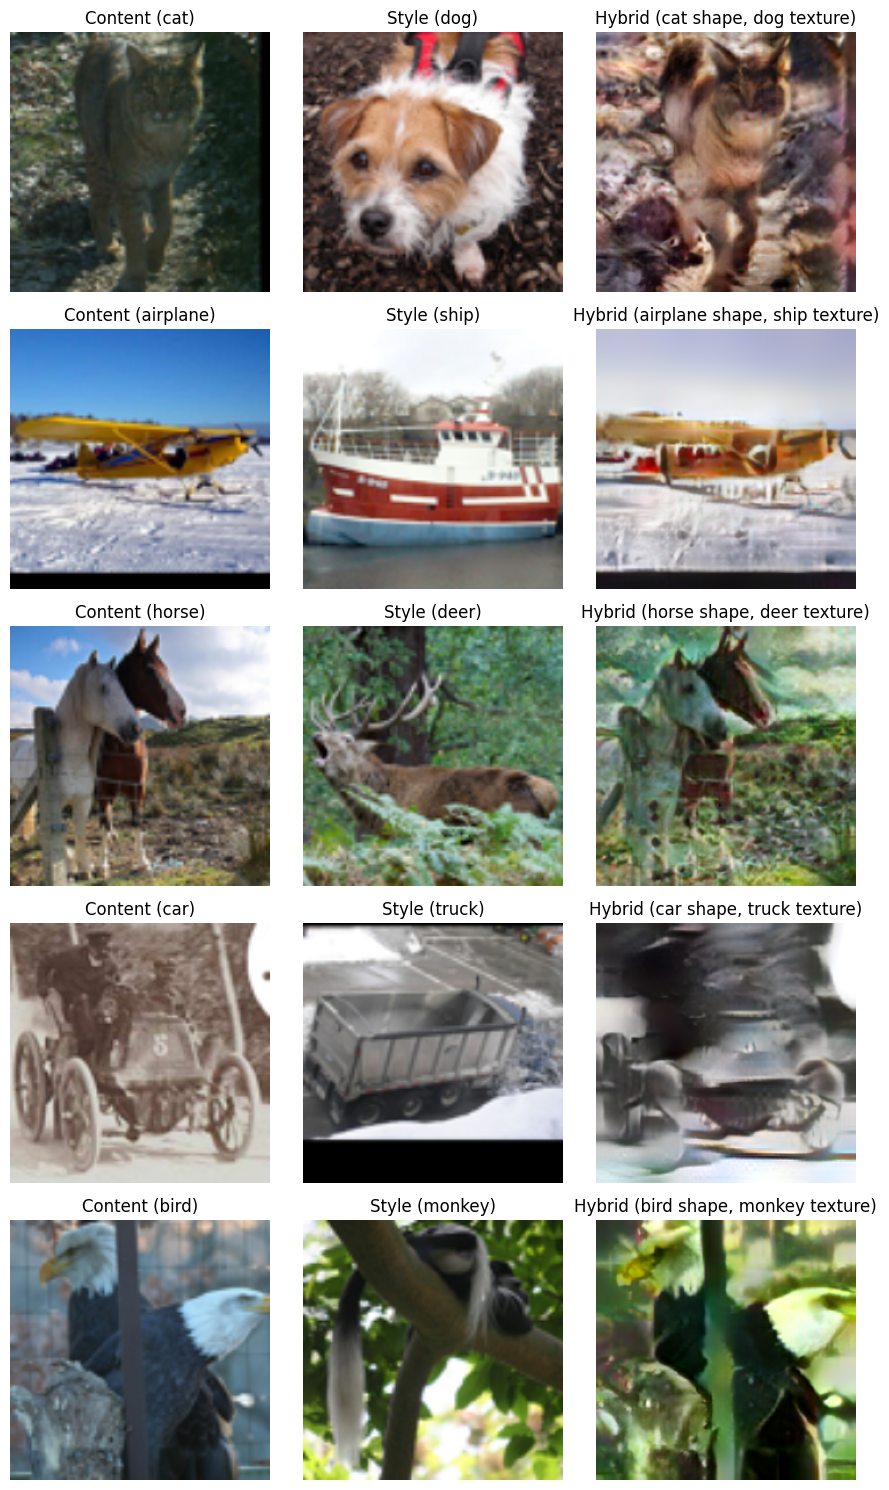

In [47]:
def show_style_transfer_grid(pairs, seed=SEED):
    rng = random.Random(seed)
    n = len(pairs)
    fig, axes = plt.subplots(n, 3, figsize=(9, 3 * n))
    if n == 1:
        axes = axes[np.newaxis, :] 

    for row, (content_cls, style_cls) in enumerate(pairs):
        content_pool = clean_images[clean_labels == class_to_idx[content_cls]]
        style_pool = clean_images[clean_labels == class_to_idx[style_cls]]

        content_img = content_pool[rng.randrange(len(content_pool))]
        style_img = style_pool[rng.randrange(len(style_pool))]
        hybrid = style_transfer_fn(content_img, style_img)

        axes[row, 0].imshow(content_img.permute(1, 2, 0)); axes[row, 0].set_title(f"Content ({content_cls})")
        axes[row, 1].imshow(style_img.permute(1, 2, 0)); axes[row, 1].set_title(f"Style ({style_cls})")
        axes[row, 2].imshow(hybrid.permute(1, 2, 0)); axes[row, 2].set_title(f"Hybrid ({content_cls} shape, {style_cls} texture)")

        for ax in axes[row]:
            ax.axis("off")

    plt.tight_layout()
    plt.show()

show_style_transfer_grid([
    ("cat", "dog"),
    ("airplane", "ship"),
    ("horse", "deer"),
    ("car", "truck"),
    ("bird", "monkey"),
])

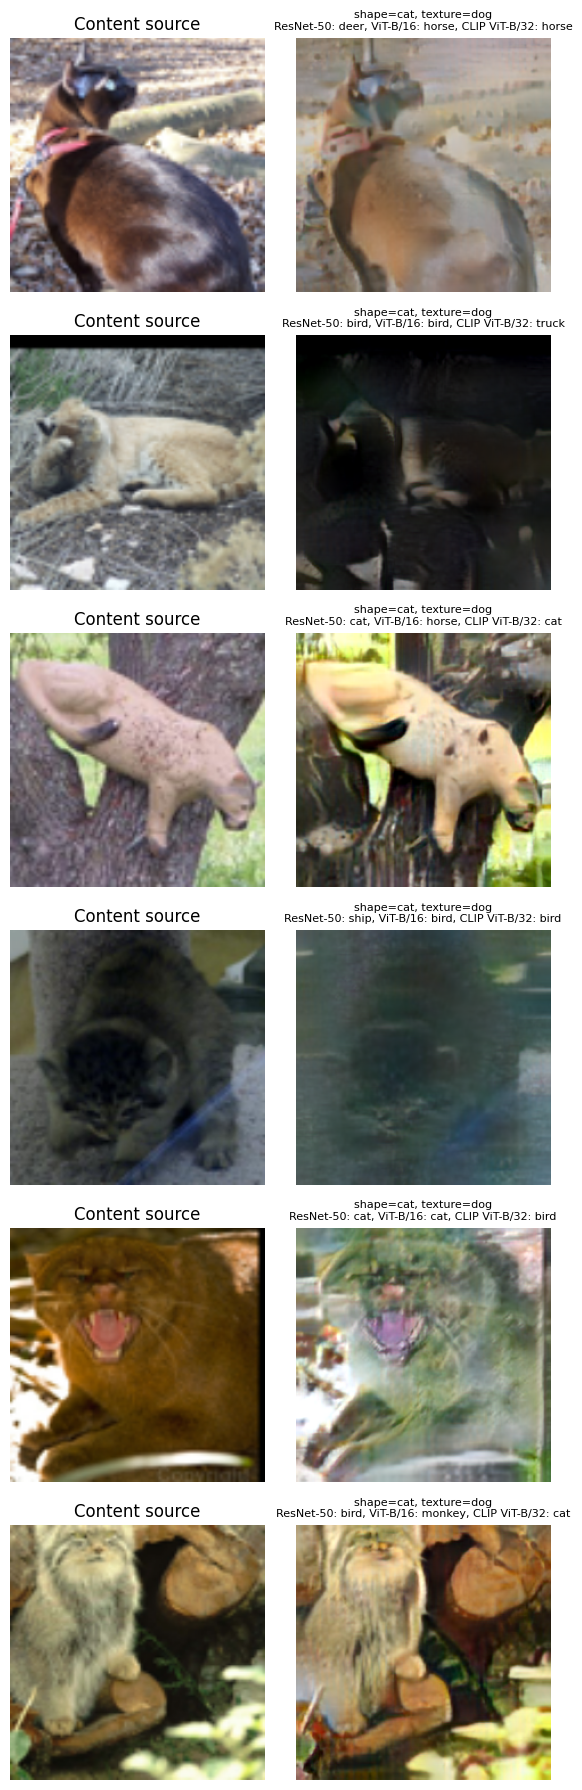

In [48]:
n_show = 6
fig, axes = plt.subplots(n_show, 2, figsize=(6, 3 * n_show))

shown = 0
for i in range(len(cue_conflict_images)):
    backbone_preds = {name: cue_results[name]["preds"][i] for name in backbones}
    content_idx, style_idx = content_labels_idx[i], style_labels_idx[i]
    votes = set(backbone_preds.values())

    if len(votes) > 1 and shown < n_show:  
        axes[shown, 0].imshow(cue_source[i].permute(1, 2, 0)); axes[shown, 0].set_title("Content source"); axes[shown, 0].axis("off")
        pred_str = ", ".join(f"{n}: {STL10_CLASSES[p]}" for n, p in backbone_preds.items())
        axes[shown, 1].imshow(cue_conflict_images[i].permute(1, 2, 0))
        axes[shown, 1].set_title(f"shape={STL10_CLASSES[content_idx]}, texture={STL10_CLASSES[style_idx]}\n{pred_str}", fontsize=8)
        axes[shown, 1].axis("off")
        shown += 1

plt.tight_layout()
plt.show()

## Translation

In [49]:
import torch.nn.functional as F

def translate_image(img_batch, dx, dy, image_size=224):
    pad_left = max(dx, 0)
    pad_right = max(-dx, 0)
    pad_top = max(dy, 0)
    pad_bottom = max(-dy, 0)
    padded = F.pad(img_batch, (pad_left, pad_right, pad_top, pad_bottom), mode="reflect")
    top = pad_bottom
    left = pad_right
    return padded[:, :, top:top + image_size, left:left + image_size]

In [50]:
DISPLACEMENTS = [0, 8, 16, 32]
DIRECTIONS = {
    "right": (1, 0),
    "left": (-1, 0),
    "down": (0, 1),
    "up": (0, -1),
}

In [51]:
translation_results = {}
for name in all_res:
    translation_results[name] = {
        "accuracy": [],
        "consistency": []
    }
for delta in DISPLACEMENTS:
    if delta == 0:
        combined = eval_results(clean_images, clean_labels)
        for name in translation_results:
            translation_results[name]["accuracy"].append(combined[name]["accuracy"])
            translation_results[name]["consistency"].append(1.0) 
        continue
    acc_dir ={}
    for name in translation_results:
        acc_dir[name]=[]
    cons_dir = {}
    for name in translation_results:
        cons_dir[name] = []
    for direction_name, (sx, sy) in DIRECTIONS.items():
        dx, dy = sx * delta, sy * delta
        shifted_images = translate_image(clean_images, dx, dy)
        shifted_res = eval_results(shifted_images, clean_labels)
        for name in translation_results:
            acc_dir[name].append(shifted_res[name]["accuracy"])
            consistency = (shifted_res[name]["preds"] == all_res[name]["preds"]).mean()
            cons_dir[name].append(consistency)
    for name in translation_results:
        translation_results[name]["accuracy"].append(np.mean(acc_dir[name]))
        translation_results[name]["consistency"].append(np.mean(cons_dir[name]))

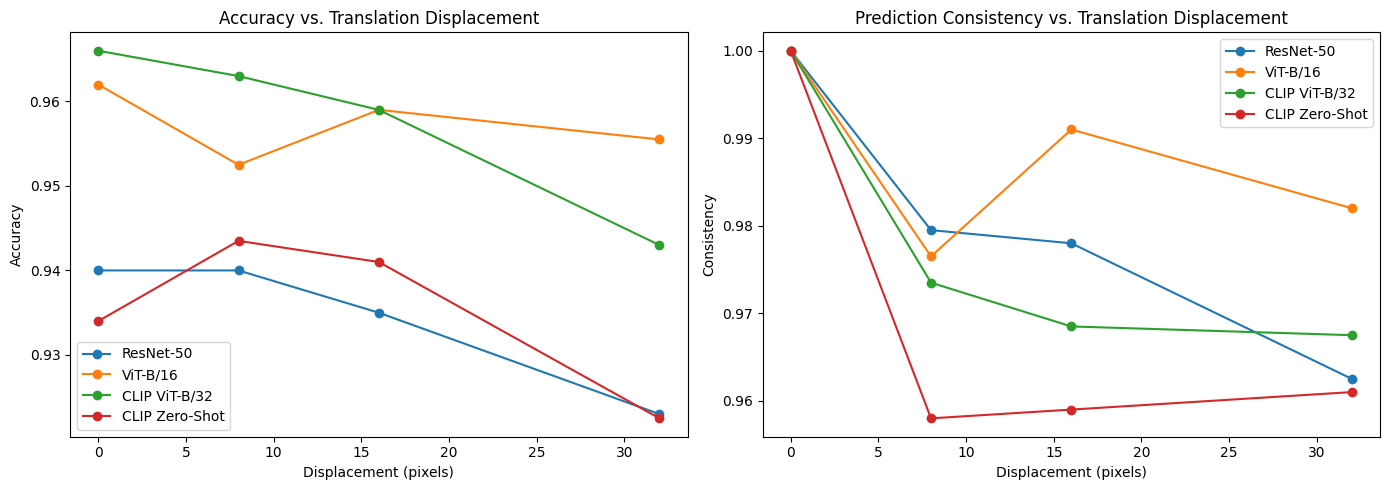

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name in translation_results:
    axes[0].plot(DISPLACEMENTS, translation_results[name]["accuracy"], marker="o", label=name)
    axes[1].plot(DISPLACEMENTS, translation_results[name]["consistency"], marker="o", label=name)

axes[0].set_xlabel("Displacement (pixels)")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Accuracy vs. Translation Displacement")
axes[0].legend()

axes[1].set_xlabel("Displacement (pixels)")
axes[1].set_ylabel("Consistency")
axes[1].set_title("Prediction Consistency vs. Translation Displacement")
axes[1].legend()

plt.tight_layout()
plt.savefig("translation_results.png", dpi=150)
plt.show()

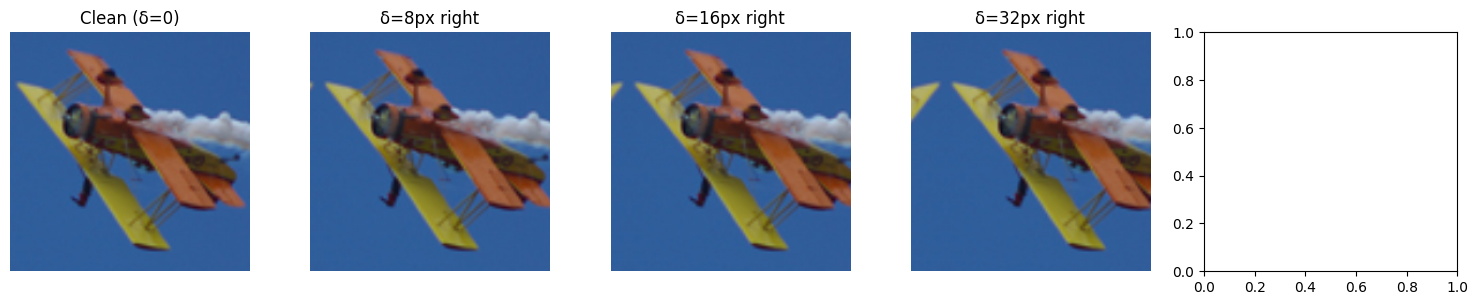

In [53]:
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
idx = 0  

axes[0].imshow(clean_images[idx].permute(1, 2, 0)); axes[0].set_title("Clean (δ=0)"); axes[0].axis("off")
for i, delta in enumerate([8, 16, 32], start=1):
    shifted = translate_image(clean_images[idx:idx+1], dx=delta, dy=0)
    axes[i].imshow(shifted[0].permute(1, 2, 0))
    axes[i].set_title(f"δ={delta}px right")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## Permutation

In [54]:
def shuffle_patches(img, grid_size=4, seed=None):
    C, H, W = img.shape
    ph, pw = H // grid_size, W // grid_size  
    patches = []
    for i in range(grid_size):
        for j in range(grid_size):
            patch = img[:, i*ph:(i+1)*ph, j*pw:(j+1)*pw]
            patches.append(patch)

    np.random.seed(seed)
    n=len(patches)
    perm = np.random.permutation(len(patches))
    while np.array_equal(perm, np.arange(n)):   
        perm = np.random.permutation(len(patches))
        
    shuffled_patches = []
    for p in perm:
        shuffled_patches.append(patches[p])
    rows = []
    for i in range(grid_size):
        row = torch.cat(shuffled_patches[i*grid_size:(i+1)*grid_size], dim=2) 
        rows.append(row)
    shuffled_img = torch.cat(rows, dim=1) 
    return shuffled_img


def build_shuffled_dataset(images, base_seed=SEED, grid_size=4):
    shuffled = []
    for idx, img in enumerate(images):
        per_image_seed = base_seed + idx
        shuffled.append(shuffle_patches(img, grid_size=grid_size, seed=per_image_seed))
    return torch.stack(shuffled)

In [55]:
shuffled_images = build_shuffled_dataset(clean_images, base_seed=SEED, grid_size=4)
patch_results = eval_results(shuffled_images, clean_labels)

print(f"{'Model':<18} {'Accuracy':>10} {'Macro-F1':>10} {'Mean Conf':>10}")
for name, res in patch_results.items():
    print(f"{name:<18} {res['accuracy']:>10.4f} {res['macro_f1']:>10.4f} {res['mean_max_confidence']:>10.4f}")

Model                Accuracy   Macro-F1  Mean Conf
ResNet-50              0.8080     0.8070     0.5922
ViT-B/16               0.8740     0.8751     0.6302
CLIP ViT-B/32          0.7100     0.7087     0.1153
CLIP Zero-Shot         0.7760     0.7725     0.7610


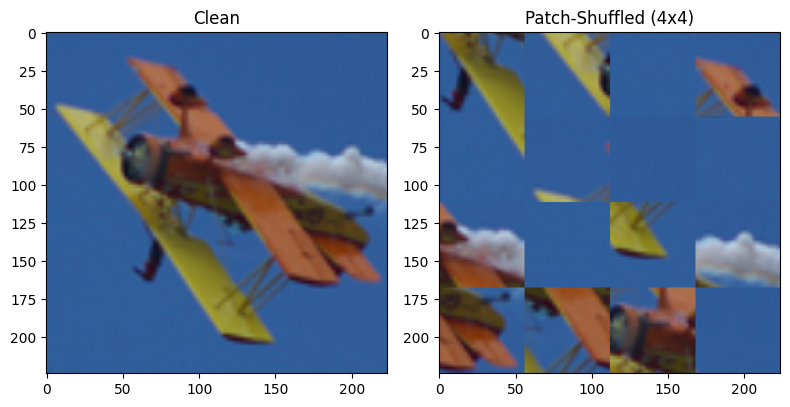

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(clean_images[0].permute(1, 2, 0))
axes[0].set_title("Clean")
axes[1].imshow(shuffled_images[0].permute(1, 2, 0))
axes[1].set_title("Patch-Shuffled (4x4)")
plt.tight_layout()
plt.show()

In [57]:
print(f"\n{'Model':<18} {'Acc Drop':>10} {'Consistency':>12}")
for name in patch_results:
    acc_drop = all_res[name]["accuracy"] - patch_results[name]["accuracy"]
    consistency = (patch_results[name]["preds"] == all_res[name]["preds"]).mean()
    print(f"{name:<18} {acc_drop:>10.4f} {consistency:>12.4f}")


Model                Acc Drop  Consistency
ResNet-50              0.1320       0.8420
ViT-B/16               0.0880       0.9000
CLIP ViT-B/32          0.2560       0.7160
CLIP Zero-Shot         0.1580       0.7880


## Representaton Analysis

In [58]:
translation_example = translate_image(clean_images, dx=16, dy=0)  # one representative displacement
conditions_for_representation = {
    "Grayscale": (clean_images, gray),
    "Translation (16px right)": (clean_images, translation_example),
    "Patch Shuffle": (clean_images, shuffled_images),
    "Cue Conflict": (cue_source, cue_conflict_images),
}

In [59]:
def cosine_stability(clean_feats, transformed_feats):
    clean_norm = clean_feats / clean_feats.norm(dim=1, keepdim=True)
    trans_norm = transformed_feats / transformed_feats.norm(dim=1, keepdim=True)
    cos_sim = (clean_norm * trans_norm).sum(dim=1)
    return cos_sim.mean().item()

@torch.no_grad()
def get_feats_for_images(images, name, model):
    mean, std = BACKBONE_STATS[name]
    normed = normalize_batch(images.to(device), mean, std)
    feats = model(normed)
    if feats.ndim > 2:
        feats = feats.flatten(1)
    return feats.cpu()

stability_results = {}
condition_feats_paired = {} 
for cond_name, (clean_side, trans_side) in conditions_for_representation.items():
    stability_results[cond_name] = {}
    condition_feats_paired[cond_name] = {}
    for name, (model,_,_) in backbones.items():
        clean_side_feats = get_feats_for_images(clean_side, name, model)
        trans_side_feats = get_feats_for_images(trans_side, name, model)
        I_T = cosine_stability(clean_side_feats, trans_side_feats)
        stability_results[cond_name][name] = I_T
        condition_feats_paired[cond_name][name] = (clean_side_feats, trans_side_feats)

print(f"{'Condition':<28} {'ResNet-50':>10} {'ViT-B/16':>10} {'CLIP':>10}")
for cond_name, res in stability_results.items():
    print(f"{cond_name:<28} {res['ResNet-50']:>10.4f} {res['ViT-B/16']:>10.4f} {res['CLIP ViT-B/32']:>10.4f}")

Condition                     ResNet-50   ViT-B/16       CLIP
Grayscale                        0.7981     0.7316     0.8850
Translation (16px right)         0.9442     0.9766     0.9625
Patch Shuffle                    0.6938     0.6270     0.7500
Cue Conflict                     0.4367     0.4378     0.7746


In [60]:
def fit_shared_projection(backbone_name, seed=SEED):
    all_feats = []
    source_labels = []
    class_labels = []
    clean_feats, _ = condition_feats_paired["Grayscale"][backbone_name]
    all_feats.append(clean_feats.numpy())
    source_labels += ["clean"] * len(clean_feats)
    class_labels += clean_labels.numpy().tolist()
    for cond_name, (clean_side, trans_side) in conditions_for_representation.items():
        _, trans_feats = condition_feats_paired[cond_name][backbone_name]
        all_feats.append(trans_feats.numpy())
        source_labels += [cond_name] * len(trans_feats)
        if cond_name == "Cue Conflict":
            class_labels += content_labels_idx.tolist()
        else:
            class_labels += clean_labels.numpy().tolist()
    combined = np.concatenate(all_feats, axis=0)
    reducer = TSNE(n_components=2,perplexity=30, random_state=seed)
    projected = reducer.fit_transform(combined)
    return projected, np.array(source_labels), np.array(class_labels)

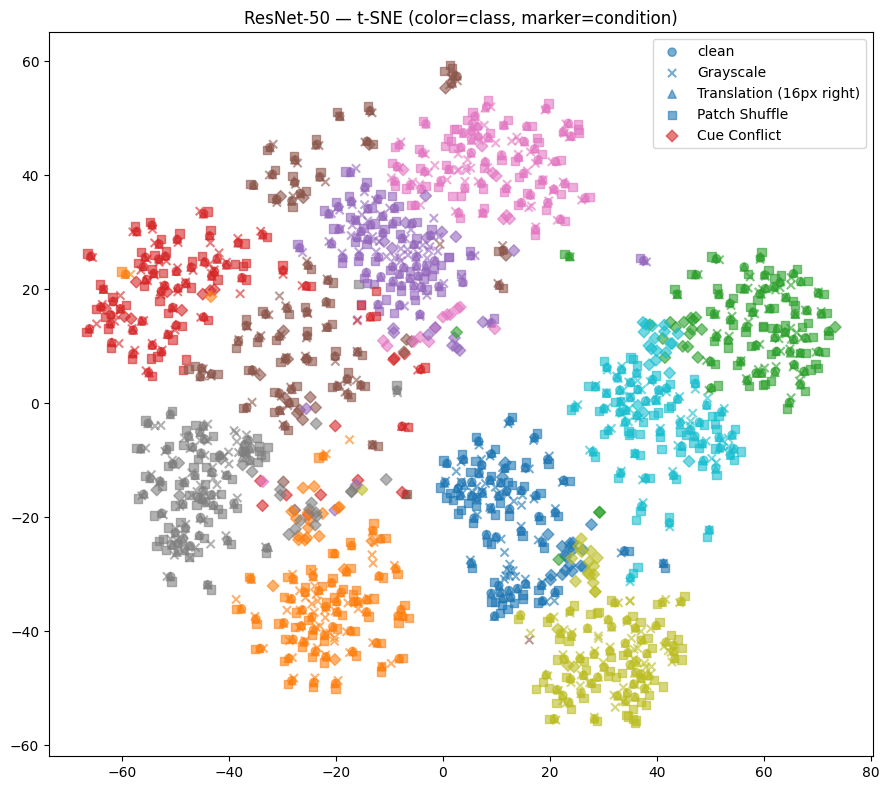

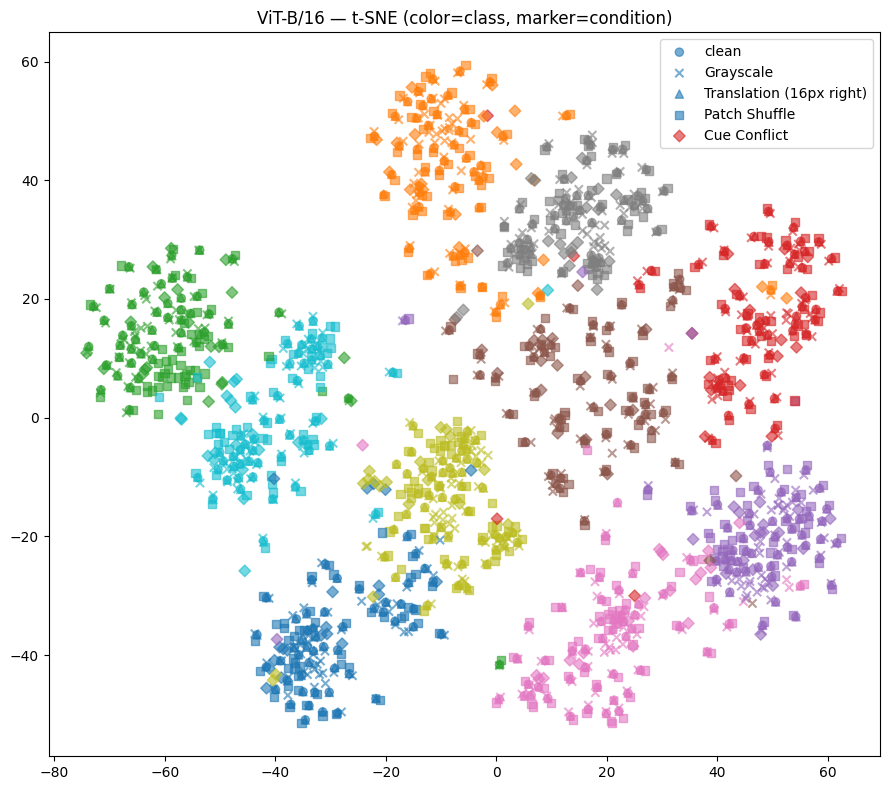

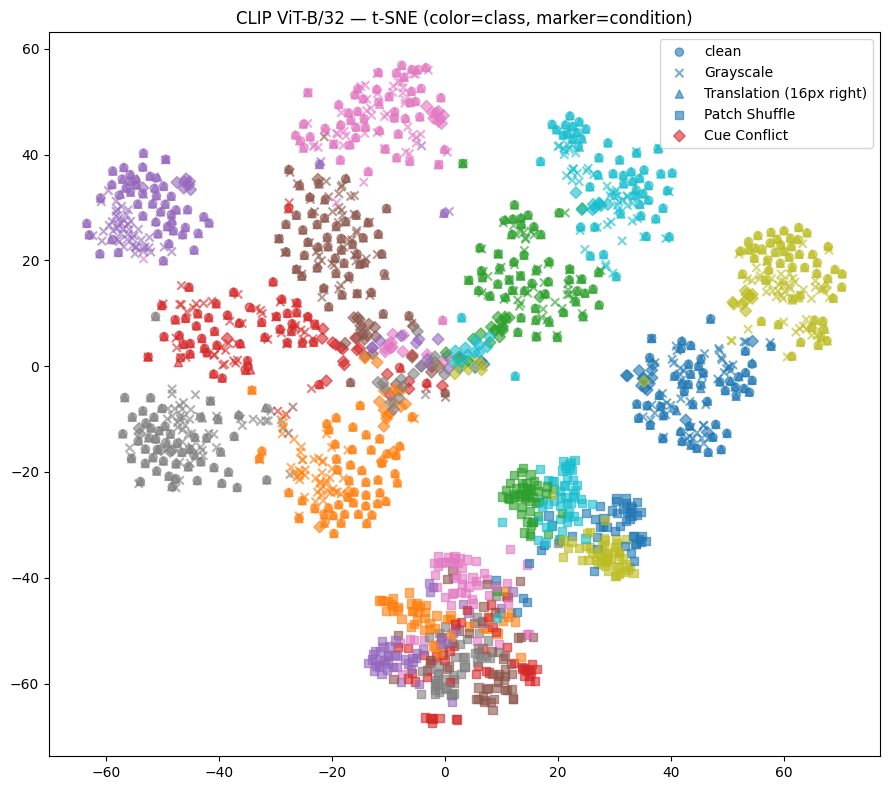

In [61]:
def plot_backbone_projection(backbone_name):
    projected, source_labels, class_labels = fit_shared_projection(backbone_name)
    fig, ax = plt.subplots(figsize=(9, 8))
    markers = {"clean": "o", "Grayscale": "x", "Translation (16px right)": "^",
               "Patch Shuffle": "s", "Cue Conflict": "D"}
    for source in markers:
        mask = source_labels == source
        ax.scatter(projected[mask, 0], projected[mask, 1], c=class_labels[mask],
                   cmap="tab10", marker=markers[source], label=source, alpha=0.6, s=35)
    ax.set_title(f"{backbone_name} — t-SNE (color=class, marker=condition)")
    ax.legend()
    plt.tight_layout()
    plt.savefig(f"representation_{backbone_name.replace('/', '-')}.png", dpi=150)
    plt.show()
for name in backbones:
    plot_backbone_projection(name)

In [62]:
print(f"{'Condition':<12} {'Model':<18} {'Accuracy':>10} {'Macro-F1':>10} {'Mean Conf':>10}")
for cond_name, results_dict in [("Clean", all_res), ("Grayscale", gray_res),
                                  ("Hue Shift", hue_res), ("Patch Shuffle", patch_results)]:
    for name, res in results_dict.items():
        print(f"{cond_name:<12} {name:<18} {res['accuracy']:>10.4f} {res['macro_f1']:>10.4f} {res['mean_max_confidence']:>10.4f}")

Condition    Model                Accuracy   Macro-F1  Mean Conf
Clean        ResNet-50              0.9400     0.9401     0.4995
Clean        ViT-B/16               0.9620     0.9623     0.7799
Clean        CLIP ViT-B/32          0.9660     0.9657     0.1276
Clean        CLIP Zero-Shot         0.9340     0.9328     0.9264
Grayscale    ResNet-50              0.9180     0.9187     0.5330
Grayscale    ViT-B/16               0.9420     0.9422     0.7846
Grayscale    CLIP ViT-B/32          0.9200     0.9192     0.1249
Grayscale    CLIP Zero-Shot         0.8980     0.8976     0.9139
Hue Shift    ResNet-50              0.8980     0.8987     0.5477
Hue Shift    ViT-B/16               0.9180     0.9172     0.7573
Hue Shift    CLIP ViT-B/32          0.9280     0.9285     0.1232
Hue Shift    CLIP Zero-Shot         0.9080     0.9069     0.8989
Patch Shuffle ResNet-50              0.8080     0.8070     0.5922
Patch Shuffle ViT-B/16               0.8740     0.8751     0.6302
Patch Shuffle CLIP ViT-

In [64]:
print(f"{'Condition':<28} {'Model':<18} {'Acc Drop':>10} {'Consistency':>12} {'I_T':>8}")
for cond_name in ["Grayscale", "Translation (16px right)", "Patch Shuffle", "Cue Conflict"]:
    results_lookup = {"Grayscale": gray_res, "Patch Shuffle": patch_results}.get(cond_name)
    for name in backbones:
        I_T = stability_results[cond_name][name]
        if results_lookup:
            acc_drop = all_res[name]["accuracy"] - results_lookup[name]["accuracy"]
            consistency = (results_lookup[name]["preds"] == all_res[name]["preds"]).mean()
            print(f"{cond_name:<28} {name:<18} {acc_drop:>10.4f} {consistency:>12.4f} {I_T:>8.4f}")
        else:
            print(f"{cond_name:<28} {name:<18} {'n/a':>10} {'n/a':>12} {I_T:>8.4f}")

Condition                    Model                Acc Drop  Consistency      I_T
Grayscale                    ResNet-50              0.0220       0.9460   0.7981
Grayscale                    ViT-B/16               0.0200       0.9560   0.7316
Grayscale                    CLIP ViT-B/32          0.0460       0.9380   0.8850
Translation (16px right)     ResNet-50                 n/a          n/a   0.9442
Translation (16px right)     ViT-B/16                  n/a          n/a   0.9766
Translation (16px right)     CLIP ViT-B/32             n/a          n/a   0.9625
Patch Shuffle                ResNet-50              0.1320       0.8420   0.6938
Patch Shuffle                ViT-B/16               0.0880       0.9000   0.6270
Patch Shuffle                CLIP ViT-B/32          0.2560       0.7160   0.7500
Cue Conflict                 ResNet-50                 n/a          n/a   0.4367
Cue Conflict                 ViT-B/16                  n/a          n/a   0.4378
Cue Conflict                